--- PROJECT 8: AUTOMATED LAB AUDITOR SUCCESSFUL ---

Quality Control Summary:
Quality_Assurance_Status
APPROVED (QA PASS)    57
REJECTED (QA FAIL)    43
Name: count, dtype: int64


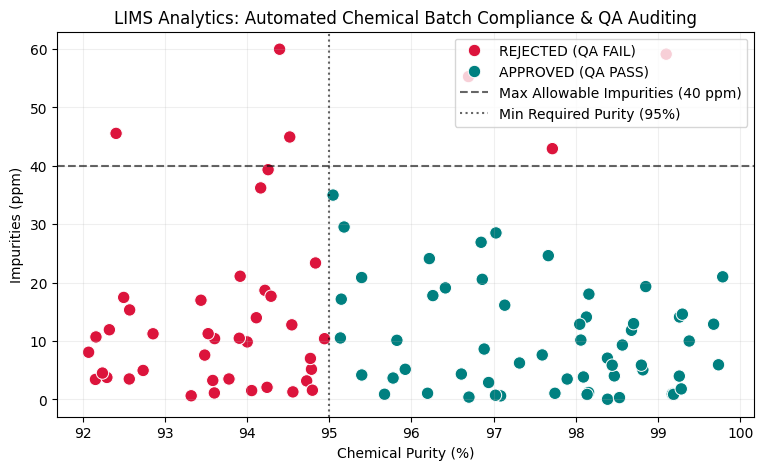

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Simulate 100 chemical batches of raw laboratory validation metrics
np.random.seed(55)
batch_size = 100

data = {
    'Batch_ID': [f"CH_BATCH_{i:03d}" for i in range(1, batch_size + 1)],
    'Chemical_Purity_Percent': np.random.uniform(92.0, 99.9, batch_size),
    'Impurities_ppm': np.random.exponential(scale=15, size=batch_size),
    'Moisture_Content_Percent': np.random.uniform(0.05, 1.5, batch_size)
}
df = pd.DataFrame(data)

# 2. LIMS Automated Quality Assurance Logic Filter
# Conditions: Purity must be >= 95% AND Impurities must be <= 40 ppm
def audit_batch(row):
    if row['Chemical_Purity_Percent'] >= 95.0 and row['Impurities_ppm'] <= 40.0:
        return 'APPROVED (QA PASS)'
    return 'REJECTED (QA FAIL)'

df['Quality_Assurance_Status'] = df.apply(audit_batch, axis=1)

# 3. Print automated summary matrix logs
print("--- PROJECT 8: AUTOMATED LAB AUDITOR SUCCESSFUL ---")
print("\nQuality Control Summary:")
print(df['Quality_Assurance_Status'].value_counts())

# 4. Generate the Industrial Quality Control Scatter Plot
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Chemical_Purity_Percent', y='Impurities_ppm',
                hue='Quality_Assurance_Status', palette={'APPROVED (QA PASS)': 'teal', 'REJECTED (QA FAIL)': 'crimson'}, s=80)
plt.axhline(y=40.0, color='black', linestyle='--', alpha=0.6, label='Max Allowable Impurities (40 ppm)')
plt.axvline(x=95.0, color='black', linestyle=':', alpha=0.6, label='Min Required Purity (95%)')
plt.title('LIMS Analytics: Automated Chemical Batch Compliance & QA Auditing')
plt.xlabel('Chemical Purity (%)')
plt.ylabel('Impurities (ppm)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()
